## Logistic Regression

## binary Logistic Regression
Logistic regression is a statistical method for modeling the probability of a binary outcome (like Yes/No, 0/1, True/False) based on one or more predictor variables, fitting an S-shaped logistic (sigmoid) curve to the data to output probabilities between 0 and 1, and then using a threshold (often 0.5) for classification.

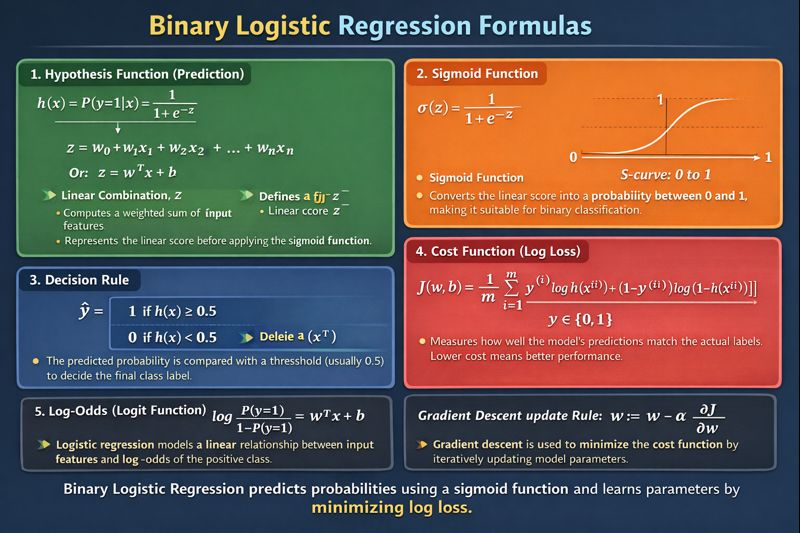

## How it works 
## Predicts probabilities:
It estimates the probability (\(p\)) that an event occurs, given input features.
## Uses the Sigmoid Function:
It transforms a linear combination of inputs into a probability using the logistic (sigmoid) function, which squashes the output between 0 and 1.Calculates 
## "Log-Odds":
It models the natural logarithm of the odds (the ratio of probability of success to probability of failure, \(p/(1-p)\)) as a linear function of the predictors.
## Classifies:
If the predicted probability is above a set threshold (e.g., 0.5), it classifies the outcome as one class (e.g., "Yes"), otherwise as the other (e.g., "No"). 

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions

In [2]:
np.random.seed(42)
n_samples = 100
feature1 = np.random.rand(n_samples)
feature2 = np.random.rand(n_samples)
linear_combination = 3 * feature1 + 2 * feature2 - 2
prob = 1 / (1 + np.exp(-linear_combination))
target = (prob > 0.5).astype(int)
df = pd.DataFrame({
    "feature1": feature1,
    "feature2": feature2,
    "target": target
})

df

,feature1,feature2,target
0,0.374540,0.031429,0
1,0.950714,0.636410,1
2,0.731994,0.314356,1
3,0.598658,0.508571,1
4,0.156019,0.907566,1
...,...,...,...
95,0.493796,0.349210,1
96,0.522733,0.725956,1
97,0.427541,0.897110,1
98,0.025419,0.887086,0


In [3]:
X=df[["feature1","feature2"]]
y=df["target"]

In [4]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [5]:
model = LogisticRegression(penalty='l1',solver="saga",max_iter=200,class_weight="balanced")
model.fit(X_train,y_train)
print(model)

LogisticRegression(class_weight='balanced', max_iter=200, penalty='l1',
                   solver='saga')


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [6]:
y_pred=model.predict(X_train)

In [7]:
print("Accuracy_score: \n",accuracy_score(y_train, y_pred))
print("Classification_report: \n",classification_report(y_train, y_pred))
print("Confusion_matrix: \n",confusion_matrix(y_train, y_pred))

Accuracy_score: 
 0.975
Classification_report: 
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        31
           1       1.00      0.96      0.98        49

    accuracy                           0.97        80
   macro avg       0.97      0.98      0.97        80
weighted avg       0.98      0.97      0.98        80

Confusion_matrix: 
 [[31  0]
 [ 2 47]]


In [8]:
yy_pred=model.predict(X_test)

In [9]:
print("Accuracy_score: \n",accuracy_score(y_test, yy_pred))
print("Classification_report: \n",classification_report(y_test, yy_pred))
print("Confusion_matrix: \n",confusion_matrix(y_test, yy_pred))

Accuracy_score: 
 1.0
Classification_report: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        14

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20

Confusion_matrix: 
 [[ 6  0]
 [ 0 14]]


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


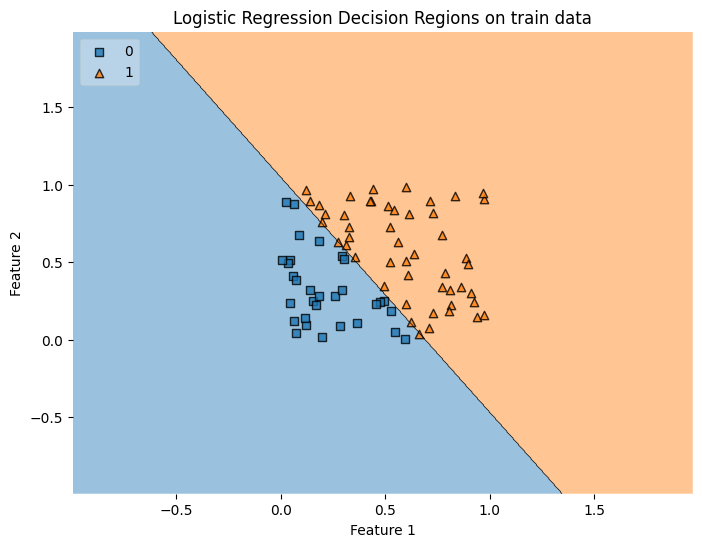

In [10]:
plt.figure(figsize=(8, 6))
plot_decision_regions(X=X_train.values,y=y_train.values,clf=model,legend=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Regions on train data')
plt.show()


C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


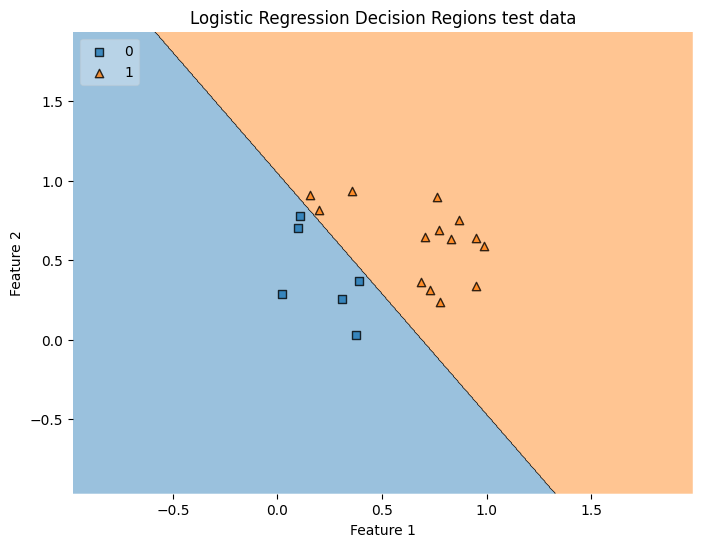

In [11]:
plt.figure(figsize=(8, 6))
plot_decision_regions(X=X_test.values,y=y_test.values,clf=model,legend=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Regions test data')
plt.show()


In [12]:
model.classes_

array([0, 1])

In [13]:
model.predict([[0.156019,0.907566]])

C:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

## confusion matrix
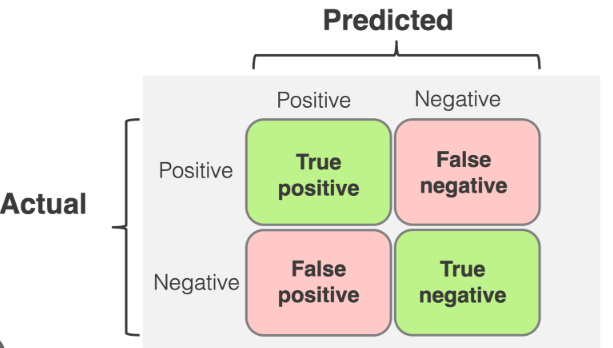

## 2nd Picture

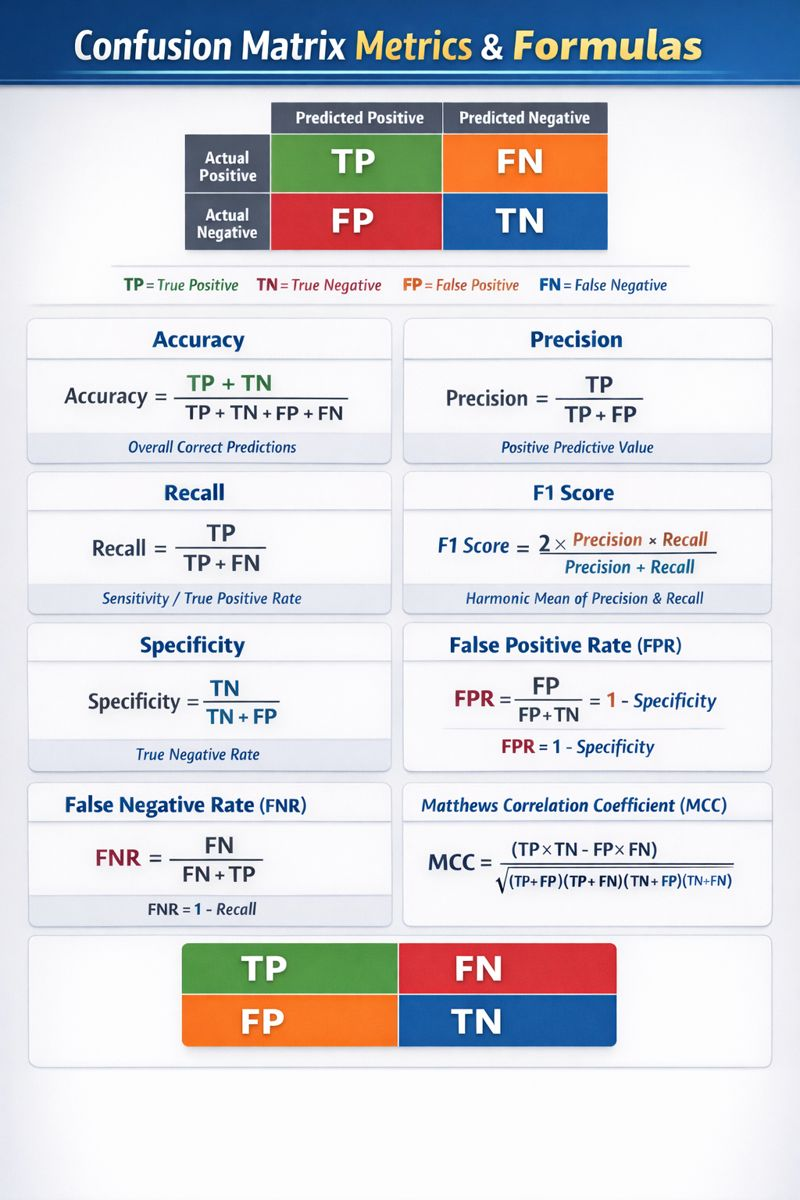


## Solver Comparison
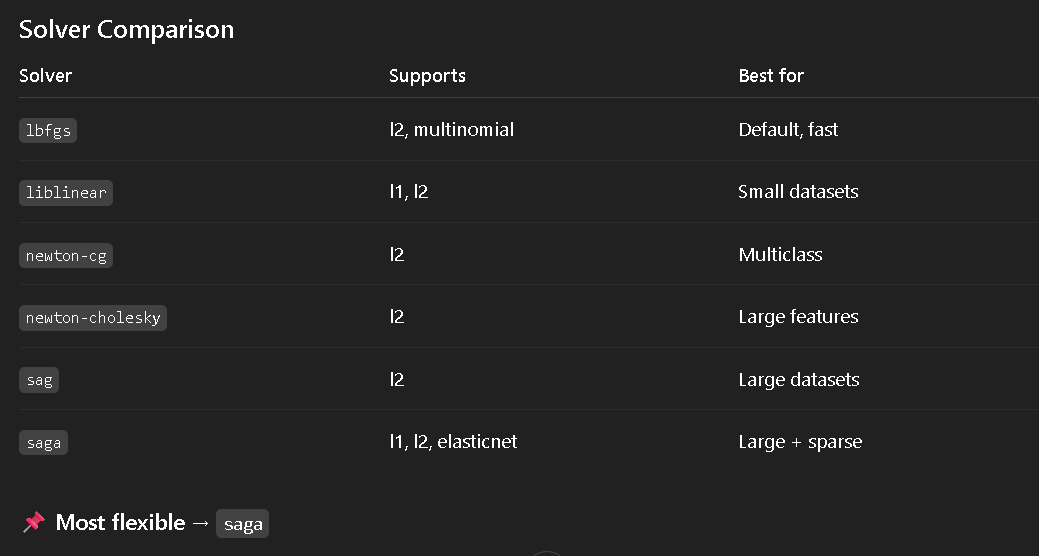